# Generated entirely by Claude - taking several iterations before it appeared to function well. Needs review.

# Plot intermediate QA flags

`flag_step2_generate-intermediate-qa-flags.ipynb` writes one intermediate flag store per `{gcm}_{var}_{scenario}_{ens}_{method}` leaf (tag), holding every individual flag in `srm.qa_flags.FLAG_LIST_TIME_VARYING` and `FLAG_LIST_TIME_INVARIANT`. `flag_step3_combine_and_write_to_source_coop.ipynb` then ORs those together into the two flags (`qa_flag_time_varying`, `qa_flag_time_invariant`) written to the production store.

This notebook plots each **individual intermediate flag** on its own -- before step 3 collapses them together -- so a flag that's only tripped for one scenario or ensemble member doesn't get lost in the combined flag. For every flag, it makes one figure per (variable, method) with panels arranged as ensemble member (rows) x scenario (columns), so all the leaves for that flag are visible side by side.

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm.qa_flags import (
    FLAG_LIST_TIME_INVARIANT,
    FLAG_LIST_TIME_VARYING,
    discover_leaves,
    get_intermediate_flags,
    parse_tag,
)

# A. Define what data arrays exist to traverse

In [2]:
# --- Run parameters --------------------------------------------------------
# Keep these in sync with the parameters used to run flag_step2 / flag_step3 for the
# run(s) you want to inspect -- this notebook reads the same intermediate flag stores
# they wrote to/from, it doesn't touch the raw pipeline output.

VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]  # , "hurs"]

GCMS = ["CESM2-WACCM"]

# Time-varying figures are slow to draw (one panel per ensemble member x scenario x
# source, stacked in blocks per flag), so they're saved here instead of rendered
# inline -- see Section D.
FIGURE_DIR = Path("./qa_flags_figures")
FIGURE_DIR.mkdir(exist_ok=True)

In [3]:
# Every run source to plot side by side. Each gets its own row in every figure below
# (ordered by SOURCE_ORDER), so e.g. a qdmsd leaf and its bcsd counterpart land in
# adjacent rows of the same figure instead of two separate figures.
#
# bcsd (v0.13.0) predates the method tier in the data tree, so its leaves parse_tag as
# method="no-method-specified" rather than "bcsd" -- and its intermediate flags were
# written under a different prefix (see flag_step3, section A, commented-out lines).
# Both are handled below via the "source" key (not the "method" column).
RUN_SOURCES = {
    "qdmsd": dict(
        branch="pr-638-global",
        root_dir="s3://carbonplan-srm/scratch/output/qa/",
        store_subset_id="global",
        bucket="carbonplan-srm",
        prefix="scratch/output/qa-intermediate-flags",
    ),
    "bcsd": dict(
        branch="v0.13.0",
        root_dir="s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/",
        store_subset_id="global",
        bucket="carbonplan-srm",
        prefix="scratch/output/qa-intermediate-flags/v0.13.0-global",
    ),
}

# Preferred left-to-right order for scenario columns; anything discovered that isn't
# listed here is appended (sorted) after these.
SCENARIO_ORDER = ["historical", "ssp245", "g6_1p5k", "g6_1p5k_end"]

# Preferred top-to-bottom order for source rows -- bcsd appended below qdmsd's rows.
SOURCE_ORDER = ["qdmsd", "bcsd"]

In [4]:
tags_by_source = {}
for source, cfg in RUN_SOURCES.items():
    [_, tags, *_rest] = discover_leaves(
        gcms=GCMS,
        branch=cfg["branch"],
        root_dir=cfg["root_dir"],
        store_subset_id=cfg["store_subset_id"],
    )
    tags_by_source[source] = tags
    print(f"{source}: {len(tags)} leaves")

/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:636: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:636: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


opened 1/1 stores on branch 'pr-638-global': CESM2-WACCM
196 leaves across 1 GCMs
qdmsd: 71 leaves
opened 1/1 stores on branch 'v0.13.0': CESM2-WACCM
86 leaves across 1 GCMs
bcsd: 31 leaves


/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:636: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1095. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:636: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:636: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


# B. Index the intermediate flag store for every leaf

In [5]:
tag_info = pd.DataFrame(
    [
        {
            "source": source,
            "tag": tag,
            "gcm": gcm,
            "variable": var,
            "scenario": scenario,
            "ensemble_member": ens,
            "method": method,
        }
        for source, tags in tags_by_source.items()
        for tag in tags
        for gcm, var, scenario, ens, method in [parse_tag(tag)]
    ]
)
tag_info = tag_info[tag_info["variable"].isin(VARIABLES)].reset_index(drop=True)
tag_info["key"] = list(zip(tag_info["source"], tag_info["tag"]))
tag_info.head()

,source,tag,gcm,variable,scenario,ensemble_member,method,key
0,qdmsd,CESM2-WACCM_pr_historical_r1i1p1f1_qdmsd,CESM2-WACCM,pr,historical,r1i1p1f1,qdmsd,"(qdmsd, CESM2-WACCM_pr_historical_r1i1p1f1_qdmsd)"
1,qdmsd,CESM2-WACCM_pr_historical_r2i1p1f1_qdmsd,CESM2-WACCM,pr,historical,r2i1p1f1,qdmsd,"(qdmsd, CESM2-WACCM_pr_historical_r2i1p1f1_qdmsd)"
2,qdmsd,CESM2-WACCM_pr_historical_r3i1p1f1_qdmsd,CESM2-WACCM,pr,historical,r3i1p1f1,qdmsd,"(qdmsd, CESM2-WACCM_pr_historical_r3i1p1f1_qdmsd)"
3,qdmsd,CESM2-WACCM_rsds_historical_r1i1p1f1_qdmsd,CESM2-WACCM,rsds,historical,r1i1p1f1,qdmsd,"(qdmsd, CESM2-WACCM_rsds_historical_r1i1p1f1_q..."
4,qdmsd,CESM2-WACCM_rsds_historical_r2i1p1f1_qdmsd,CESM2-WACCM,rsds,historical,r2i1p1f1,qdmsd,"(qdmsd, CESM2-WACCM_rsds_historical_r2i1p1f1_q..."


In [6]:
# Opening a zarr store is lazy/metadata-only, so this doesn't load any flag data yet --
# it just tells us which of FLAG_LIST_TIME_VARYING / FLAG_LIST_TIME_INVARIANT each leaf
# actually has written (a leaf can be missing a flag if e.g. its run_flag_loop cell in
# step2 hasn't been (re)run yet, or a flag like rsds_max_exceeded only ever applies to
# one variable).
#
# bcsd is an older run whose leaves predate commit c431eac ("Change tags to work with
# new directory structure"), which changed a method-less leaf's tag from a bare
# "{gcm}_{var}_{scenario}_{ens}" to "..._no-method-specified". bcsd's flags were mostly
# written under the *old* bare tag; only outside_global_plausible_range was ever
# recomputed and written under the new suffixed tag (confirmed directly against S3 --
# both stores exist side by side for every bcsd leaf). discover_leaves/parse_tag always
# hand back today's suffixed tag, so a plain lookup only ever finds the near-empty new
# store. _open_flag_dataset tries both spellings and merges them, so nothing written
# under the legacy tag is silently missed.
LEGACY_METHODLESS_SUFFIX = "_no-method-specified"


def _open_flag_dataset(tag, bucket, prefix):
    """Open `tag`'s store, and if it uses today's no-method-specified suffix, also try
    the pre-c431eac bare tag and merge the two -- current-tag variables win on overlap,
    the legacy store fills in anything only it has."""
    candidates = [tag]
    if tag.endswith(LEGACY_METHODLESS_SUFFIX):
        candidates.append(tag[: -len(LEGACY_METHODLESS_SUFFIX)])

    datasets = []
    for candidate in candidates:
        try:
            datasets.append(get_intermediate_flags(tag=candidate, bucket=bucket, prefix=prefix))
        except Exception:
            pass

    if not datasets:
        raise FileNotFoundError(f"no store found for any of {candidates}")

    merged_vars = {}
    for ds in reversed(datasets):  # candidates[0] (today's tag) applied last -> wins ties
        merged_vars.update(ds.data_vars)
    return xr.Dataset(merged_vars, coords=datasets[0].coords)


flag_datasets = {}
open_errors = []
for row in tag_info.itertuples():
    cfg = RUN_SOURCES[row.source]
    try:
        flag_datasets[row.key] = _open_flag_dataset(
            row.tag, bucket=cfg["bucket"], prefix=cfg["prefix"]
        )
    except Exception as exc:
        open_errors.append((row.source, row.tag, str(exc)))

tag_info = tag_info[tag_info["key"].isin(flag_datasets)].reset_index(drop=True)

if open_errors:
    print(f"{len(open_errors)} leaves failed to open (dropped):")
    for source, tag, err in open_errors[:20]:
        print(f"  [{source}] {tag}: {err}")
    if len(open_errors) > 20:
        print(f"  ... and {len(open_errors) - 20} more")

# Sanity check: confirms both sources actually made it into tag_info/flag_datasets. If
# a source is missing here, its leaves either weren't discovered in section A (check
# that cell's printed counts) or all failed to open above (check open_errors) -- either
# way, section D can't plot panels for a source that isn't in this count.
print(tag_info["source"].value_counts())

source
qdmsd    71
bcsd     31
Name: count, dtype: int64


In [7]:
# DIAGNOSTIC: compare what flag variables each source actually has written. Section D
# only plots a source's leaf if `flag_name in flag_datasets[key].variables`, so if
# bcsd's variable names don't match FLAG_LIST_TIME_VARYING/FLAG_LIST_TIME_INVARIANT
# (e.g. an older flag_step2 used different names, or bcsd's store only has the two
# combined flags from flag_step3 rather than the individual intermediate ones), every
# bcsd leaf gets silently filtered out of every figure -- which would explain "no bcsd
# panel, ever" rather than just gaps.
for source in RUN_SOURCES:
    sample_key = next((k for k in flag_datasets if k[0] == source), None)
    if sample_key is None:
        print(f"{source}: no leaves opened")
        continue
    print(f"{source} sample ({sample_key[1]}):")
    print(f"  {sorted(flag_datasets[sample_key].data_vars)}")

print()
print("Flags this notebook is looking for:")
print(f"  time-varying:   {FLAG_LIST_TIME_VARYING}")
print(f"  time-invariant: {FLAG_LIST_TIME_INVARIANT}")

# Union across every leaf of a source (not just one sample), so we know whether the one
# sample above is representative or whether some bcsd leaves have more/fewer flags.
print()
for source in RUN_SOURCES:
    union = set()
    for key, ds in flag_datasets.items():
        if key[0] == source:
            union |= set(ds.data_vars)
    print(
        f"{source}: union of flag variables across all {sum(1 for k in flag_datasets if k[0] == source)} leaves:"
    )
    print(f"  {sorted(union)}")

qdmsd sample (CESM2-WACCM_pr_historical_r1i1p1f1_qdmsd):
  ['annual_outlier_flag', 'flipped_signhistorical_g6_1p5k', 'flipped_signhistorical_ssp245', 'outside_global_plausible_range', 'trend_distortion_historical_g6_1p5k', 'trend_distortion_historical_ssp245']
bcsd sample (CESM2-WACCM_pr_g6_1p5k_002_no-method-specified):
  ['annual_outlier_flag', 'flipped_signg6_1p5k_g6_1p5k_end', 'flipped_signhistorical_g6_1p5k', 'flipped_signssp245_g6_1p5k', 'outside_global_plausible_range', 'trend_distortion_g6_1p5k_g6_1p5k_end', 'trend_distortion_historical_g6_1p5k', 'trend_distortion_ssp245_g6_1p5k']

Flags this notebook is looking for:
  time-varying:   ['annual_outlier_flag', 'rsds_max_exceeded', 'outside_global_plausible_range', 'temperature_inconsistency']
  time-invariant: ['flipped_sign_ssp245_g6_1p5k', 'flipped_sign_historical_ssp245', 'flipped_sign_historical_g6_1p5k', 'trend_distortion_historical_ssp245', 'trend_distortion_ssp245_g6_1p5k', 'trend_distortion_historical_g6_1p5k', 'flipped_s

# C. Plotting helpers

In [8]:
ALL_FLAGS = FLAG_LIST_TIME_INVARIANT + FLAG_LIST_TIME_VARYING
TIME_VARYING_FLAGS = set(FLAG_LIST_TIME_VARYING)

# Shared color scheme for both figure types below (matches flag_step6's condensed
# summary figures): flat gray for confirmed-zero/unflagged pixels (distinct from a
# genuinely missing/unplotted one), red for flagged ones.
ZERO_COLOR = "0.7"
FLAGGED_COLOR = "red"
TIME_VARYING_CMAP = "Reds"

# Time-invariant flags are strictly 0/1 (no time-averaging), so give them a discrete
# 2-color map instead of a continuous gradient -- same gray/red scheme as the
# time-varying plots below, just without the gradient since there's only ever 0 or 1.
BINARY_CMAP = mcolors.ListedColormap([ZERO_COLOR, FLAGGED_COLOR])
BINARY_NORM = mcolors.BoundaryNorm([0, 0.5, 1], BINARY_CMAP.N)

FLAG_LABELS = {
    "annual_outlier_flag": "Annual Outlier",
    "rsds_max_exceeded": "RSDS Max Exceeded",
    "outside_global_plausible_range": "Outside Global Plausible Range",
    "temperature_inconsistency": "Temperature Inconsistency",
    "flipped_sign_historical_ssp245": "Flipped Sign (Historical − SSP2-4.5)",
    "flipped_sign_historical_g6_1p5k": "Flipped Sign (Historical − G6-1.5K)",
    "flipped_sign_ssp245_g6_1p5k": "Flipped Sign (SSP2-4.5 − G6-1.5K)",
    "flipped_sign_g6_1p5k_g6_1p5k_end": "Flipped Sign (G6-1.5K − G6-1.5K-end)",
    "trend_distortion_historical_ssp245": "Trend Distortion (Historical − SSP2-4.5)",
    "trend_distortion_historical_g6_1p5k": "Trend Distortion (Historical − G6-1.5K)",
    "trend_distortion_ssp245_g6_1p5k": "Trend Distortion (SSP2-4.5 − G6-1.5K)",
    "trend_distortion_g6_1p5k_g6_1p5k_end": "Trend Distortion (G6-1.5K − G6-1.5K-end)",
}

SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp245": "SSP2-4.5",
    "g6_1p5k": "G6-1.5K",
    "g6_1p5k_end": "G6-1.5K-end",
}


def _flag_label(flag_name):
    return FLAG_LABELS.get(flag_name, flag_name)


def _scenario_label(scenario):
    return SCENARIO_LABELS.get(scenario, scenario)


def _tighten(fig):
    """Shrink the padding a constrained-layout figure leaves by default -- otherwise
    these grids (especially the tall time-varying ones) end up with a lot of dead
    whitespace around and between panels."""
    fig.get_layout_engine().set(w_pad=0.01, h_pad=0.01, wspace=0.02, hspace=0.03)


def _sorted_scenarios(scenarios):
    known = [s for s in SCENARIO_ORDER if s in scenarios]
    unknown = sorted(s for s in scenarios if s not in SCENARIO_ORDER)
    return known + unknown


def _sorted_sources(sources):
    known = [s for s in SOURCE_ORDER if s in sources]
    unknown = sorted(s for s in sources if s not in SOURCE_ORDER)
    return known + unknown


def _candidate_names(flag_name):
    """Variable-name spellings to try for a canonical flag name. Some existing qdmsd
    leaves have flipped_sign_* written without the underscore right after "sign" (e.g.
    "flipped_signg6_1p5k_g6_1p5k_end" instead of "flipped_sign_g6_1p5k_g6_1p5k_end") --
    an older flag_step2 built the name that way before it was fixed to match
    FLAG_LIST_TIME_INVARIANT. Accept both spellings here rather than silently treating
    every leaf written under the old spelling as if it had no flag at all."""
    candidates = [flag_name]
    if flag_name.startswith("flipped_sign_"):
        candidates.append("flipped_sign" + flag_name[len("flipped_sign_") :])
    return candidates


def _resolve_flag_name(ds, flag_name):
    """The actual variable name in `ds` for `flag_name`, trying each candidate
    spelling in turn, or None if none of them are present."""
    for candidate in _candidate_names(flag_name):
        if candidate in ds.variables:
            return candidate
    return None


def load_flag_map(source, tag, flag_name):
    """(lat, lon) map for one tag/flag: mean fraction of flagged days for a
    time-varying flag, or the raw 0/1 map for a time-invariant flag."""
    ds = flag_datasets[(source, tag)]
    da = ds[_resolve_flag_name(ds, flag_name)]
    if flag_name in TIME_VARYING_FLAGS:
        da = da.mean(dim="time")
    return da.load()

In [9]:
def plot_variable_time_varying(variable, var_df):
    """One figure for `variable`: stacks one row-block per time-varying flag that has
    at least one leaf for this variable (block order follows FLAG_LIST_TIME_VARYING),
    each block containing that flag's ensemble-member rows. Columns are every
    (scenario, source) pair present across any of those flags, so a column lines up
    the same scenario/source all the way down the figure -- and a qdmsd panel still
    sits directly next to its bcsd counterpart.

    Each flag gets its own color scale and its own small horizontal colorbar sitting
    right above that block, since flagged-fraction magnitudes differ a lot between
    checks (e.g. annual_outlier_flag vs. outside_global_plausible_range aren't
    comparable on one shared scale).

    Slow to draw (one panel per ensemble member x scenario x source, stacked across
    every flag's block), so the finished figure is saved to `FIGURE_DIR` instead of
    rendered inline -- see Section D.
    """
    unit = "cell-days"
    blocks = []  # (flag_name, sorted ensembles, {(ens, scenario, source): map})
    col_pairs = set()
    for flag_name in FLAG_LIST_TIME_VARYING:
        maps = {}
        for row in var_df.itertuples():
            if _resolve_flag_name(flag_datasets[row.key], flag_name) is None:
                continue
            maps[(row.ensemble_member, row.scenario, row.source)] = load_flag_map(
                row.source, row.tag, flag_name
            )
            col_pairs.add((row.scenario, row.source))
        if maps:
            blocks.append((flag_name, sorted({k[0] for k in maps}), maps))

    if not blocks:
        print(f"--- {variable}: no time-varying flags found, skipping ---")
        return

    scenarios = _sorted_scenarios({p[0] for p in col_pairs})
    sources = _sorted_sources({p[1] for p in col_pairs})
    col_keys = [(s, src) for s in scenarios for src in sources if (s, src) in col_pairs]

    row_keys = []  # (flag_name, ens), one row per ensemble member within a flag's block
    block_rows = {}  # flag_name -> (start, end) row-index range
    for flag_name, ensembles, _maps in blocks:
        start = len(row_keys)
        row_keys += [(flag_name, ens) for ens in ensembles]
        block_rows[flag_name] = (start, len(row_keys))

    nrows, ncols = len(row_keys), len(col_keys)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(2.3 * ncols, 1.7 * nrows),
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False,
        layout="constrained",
    )
    _tighten(fig)
    fig.suptitle(f"time-varying flags — {variable}", fontsize=11)

    for flag_name, ensembles, maps in blocks:
        nonzero = [m for m in maps.values() if float(np.nansum(m > 0)) > 0]
        vmax = max((float(np.nanmax(m.where(m > 0))) for m in nonzero), default=1)
        start, end = block_rows[flag_name]

        block_mappable = None
        for i in range(start, end):
            ens = row_keys[i][1]
            for j, (scenario, source) in enumerate(col_keys):
                ax = axes[i, j]
                # Column titles only on the figure's very first row -- columns are
                # consistent across every block, so repeating them per block would
                # just be clutter. Row labels always carry the flag name (not just on
                # a block's first row), since that's the simplest way to keep a label
                # correct without tracking block-boundary bookkeeping bugs.
                if i == 0:
                    ax.set_title(f"{_scenario_label(scenario)}\n{source}", fontsize=8)
                if j == 0:
                    ax.text(
                        -0.22,
                        0.5,
                        f"{_flag_label(flag_name)} — {ens}",
                        transform=ax.transAxes,
                        rotation=90,
                        rotation_mode="anchor",
                        ha="center",
                        va="center",
                        fontsize=7,
                    )

                ax.set_xticks([])
                ax.set_yticks([])
                ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="black")

                key = (ens, scenario, source)
                if key not in maps:
                    ax.text(
                        0.5,
                        0.5,
                        "n/a",
                        transform=ax.transAxes,
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="0.6",
                    )
                    continue

                m = maps[key]
                n_flagged = float(np.nansum(m > 0))
                # Flat gray for confirmed-zero pixels, plotted *underneath* the red
                # layer below -- without this, a confirmed-zero pixel and a genuinely
                # missing/NaN one both render as blank background and are impossible
                # to tell apart.
                zero_mask = m.notnull() & (m == 0)
                xr.where(zero_mask, 1, np.nan).plot(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    cmap=mcolors.ListedColormap([ZERO_COLOR]),
                    vmin=0,
                    vmax=1,
                    add_colorbar=False,
                    add_labels=False,
                )

                # add_labels=False stops xarray's .plot() from calling its own
                # ax.set_title(...), which otherwise silently overwrites the
                # scenario/source title set above.
                if n_flagged > 0:
                    block_mappable = m.where(m > 0).plot(
                        ax=ax,
                        transform=ccrs.PlateCarree(),
                        cmap=TIME_VARYING_CMAP,
                        vmin=0,
                        vmax=vmax,
                        add_colorbar=False,
                        add_labels=False,
                    )

                ax.annotate(
                    f"{n_flagged:,.0f} {unit}",
                    xy=(0.5, -0.05),
                    xycoords="axes fraction",
                    ha="center",
                    fontsize=6,
                )

        if block_mappable is not None:
            fig.colorbar(
                block_mappable,
                ax=axes[start:end, :],
                orientation="horizontal",
                location="top",
                shrink=0.5,
                aspect=40,
                pad=0.02,
                label="mean frac. days flagged",
            )

    out_path = FIGURE_DIR / f"time_varying_{variable}.png"
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    print(f"saved -> {out_path}")

In [10]:
def plot_variable_time_invariant(variable, var_df):
    """One figure for `variable`: one row per time-invariant flag that has at least
    one leaf for this variable (row order follows FLAG_LIST_TIME_INVARIANT), one
    column per source -- so every trend_distortion_*/flipped_sign_* check for this
    variable is visible in a single figure, with qdmsd and bcsd side by side in every
    row for direct comparison.

    Each (flag, source) map is computed once per (gcm, variable, scenario-pair) from
    the ensemble mean and written identically to every leaf on both sides of that
    comparison *within a single source* (see flag_step2_generate-intermediate-qa-flags
    .ipynb, section C), so there's only one representative map to plot per cell here --
    this re-checks the "identical within a source" assumption before plotting each one.
    """
    rows = []  # (flag_name, {source: (map, n_leaves)})
    sources_present = set()
    for flag_name in FLAG_LIST_TIME_INVARIANT:
        per_source = {}
        for source in _sorted_sources(var_df["source"].unique()):
            source_df = var_df[var_df["source"] == source]
            tags_with_flag = [
                row.tag
                for row in source_df.itertuples()
                if _resolve_flag_name(flag_datasets[(source, row.tag)], flag_name) is not None
            ]
            if not tags_with_flag:
                continue

            maps = [load_flag_map(source, tag, flag_name) for tag in tags_with_flag]
            mismatched = [tag for tag, m in zip(tags_with_flag, maps) if not m.equals(maps[0])]
            if mismatched:
                print(
                    f"WARNING: {flag_name} / {variable} / {source} is NOT identical across "
                    f"all its leaves as expected -- differs for: {mismatched}"
                )

            per_source[source] = (maps[0], len(tags_with_flag))
            sources_present.add(source)

        if per_source:
            rows.append((flag_name, per_source))

    if not rows:
        print(f"--- {variable}: no time-invariant flags found, skipping ---")
        return

    sources = _sorted_sources(sources_present)
    nrows, ncols = len(rows), len(sources)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3.4 * ncols, 2.4 * nrows),
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False,
        layout="constrained",
    )
    _tighten(fig)
    fig.suptitle(f"time-invariant flags — {variable}", fontsize=11)

    mappable = None
    for i, (flag_name, per_source) in enumerate(rows):
        for j, source in enumerate(sources):
            ax = axes[i, j]
            ax.set_xticks([])
            ax.set_yticks([])
            ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
            if i == 0:
                ax.set_title(source, fontsize=9)
            if j == 0:
                ax.text(
                    -0.2,
                    0.5,
                    _flag_label(flag_name),
                    transform=ax.transAxes,
                    rotation=90,
                    rotation_mode="anchor",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

            if source not in per_source:
                ax.text(
                    0.5,
                    0.5,
                    "n/a",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="0.6",
                )
                continue

            m, n_leaves = per_source[source]
            n_flagged = float(np.nansum(m > 0))
            mappable = m.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=BINARY_CMAP,
                norm=BINARY_NORM,
                add_colorbar=False,
                add_labels=False,
            )
            ax.annotate(
                f"{n_flagged:,.0f} cells ({n_leaves} leaves)",
                xy=(0.5, -0.05),
                xycoords="axes fraction",
                ha="center",
                fontsize=7,
            )

    if mappable is not None:
        cbar = fig.colorbar(
            mappable,
            ax=axes,
            orientation="horizontal",
            location="top",
            shrink=0.4,
            aspect=30,
            pad=0.02,
            ticks=[0.25, 0.75],
        )
        cbar.ax.set_xticklabels(["0", "1"])
        cbar.set_label("flagged")

    plt.show()
    plt.close(fig)

# D. Plot every variable

Loops over every variable (in VARIABLES order). For each one, makes two figures:

- `plot_variable_time_varying`: every time-varying flag that has at least one leaf for this variable, stacked as row-blocks (one block per flag, ensemble members within a block), columns are every (scenario, source) pair present -- so qdmsd and bcsd sit side by side, and all of a variable's time-varying checks are visible in one figure instead of one figure per check.
- `plot_variable_time_invariant`: every time-invariant flag that has at least one leaf for this variable, one row per flag, one column per source -- same idea, one figure per variable instead of one per (flag, variable).

A flag that only applies to some variables (e.g. `rsds_max_exceeded`, or a `trend_distortion_*` that only covers two scenarios) simply contributes fewer rows/blocks to that variable's figure, or none at all if it doesn't apply.

In [11]:
present_variables = [v for v in VARIABLES if v in tag_info["variable"].unique()]

=== tas (24 leaves) ===


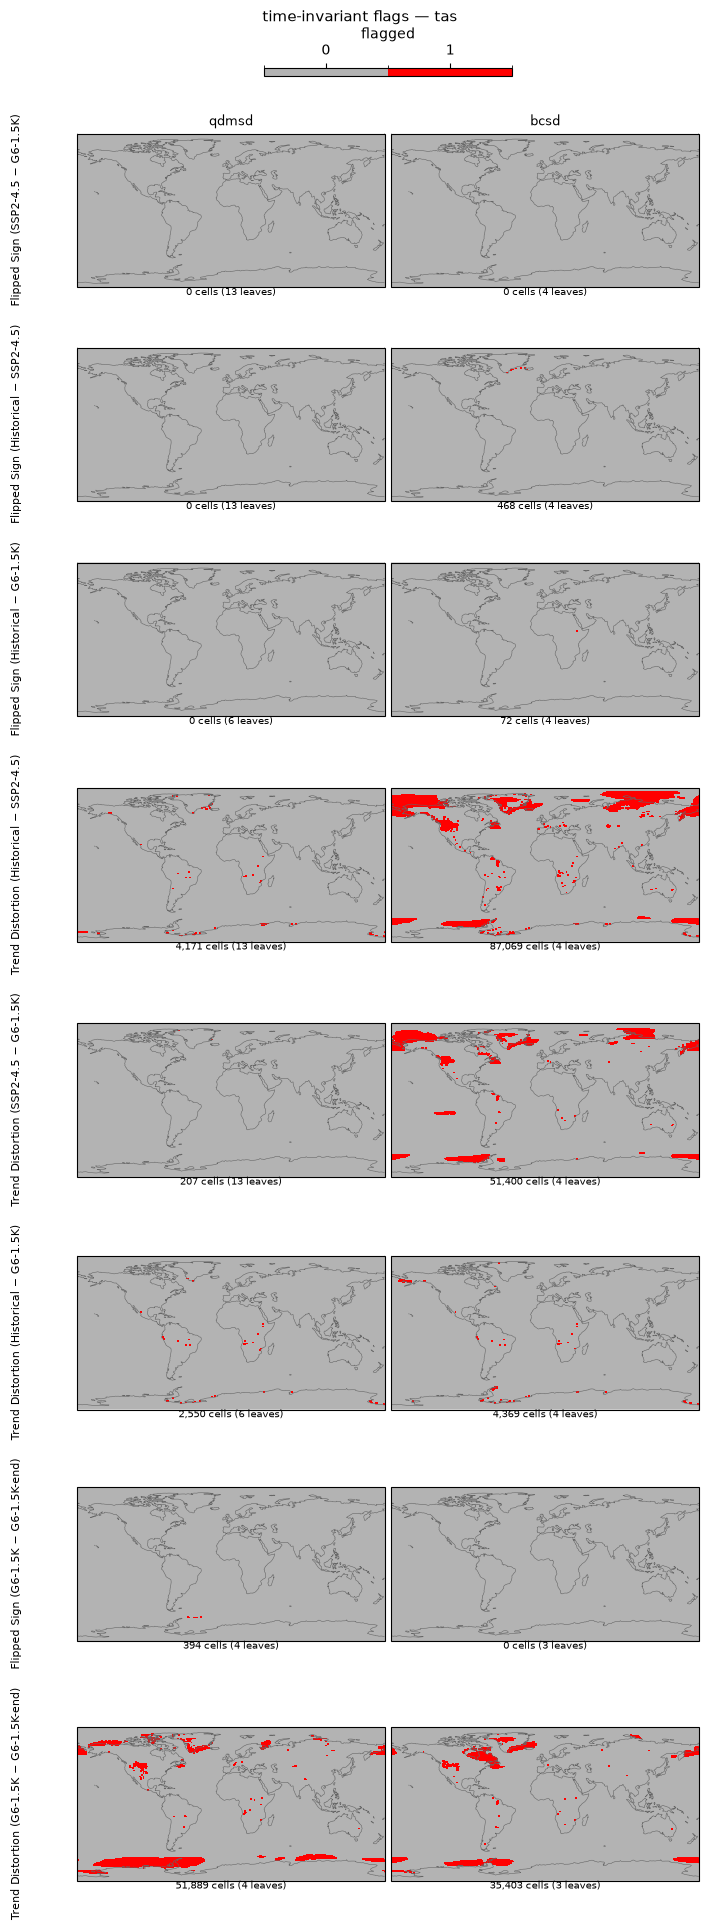

=== tasmax (15 leaves) ===


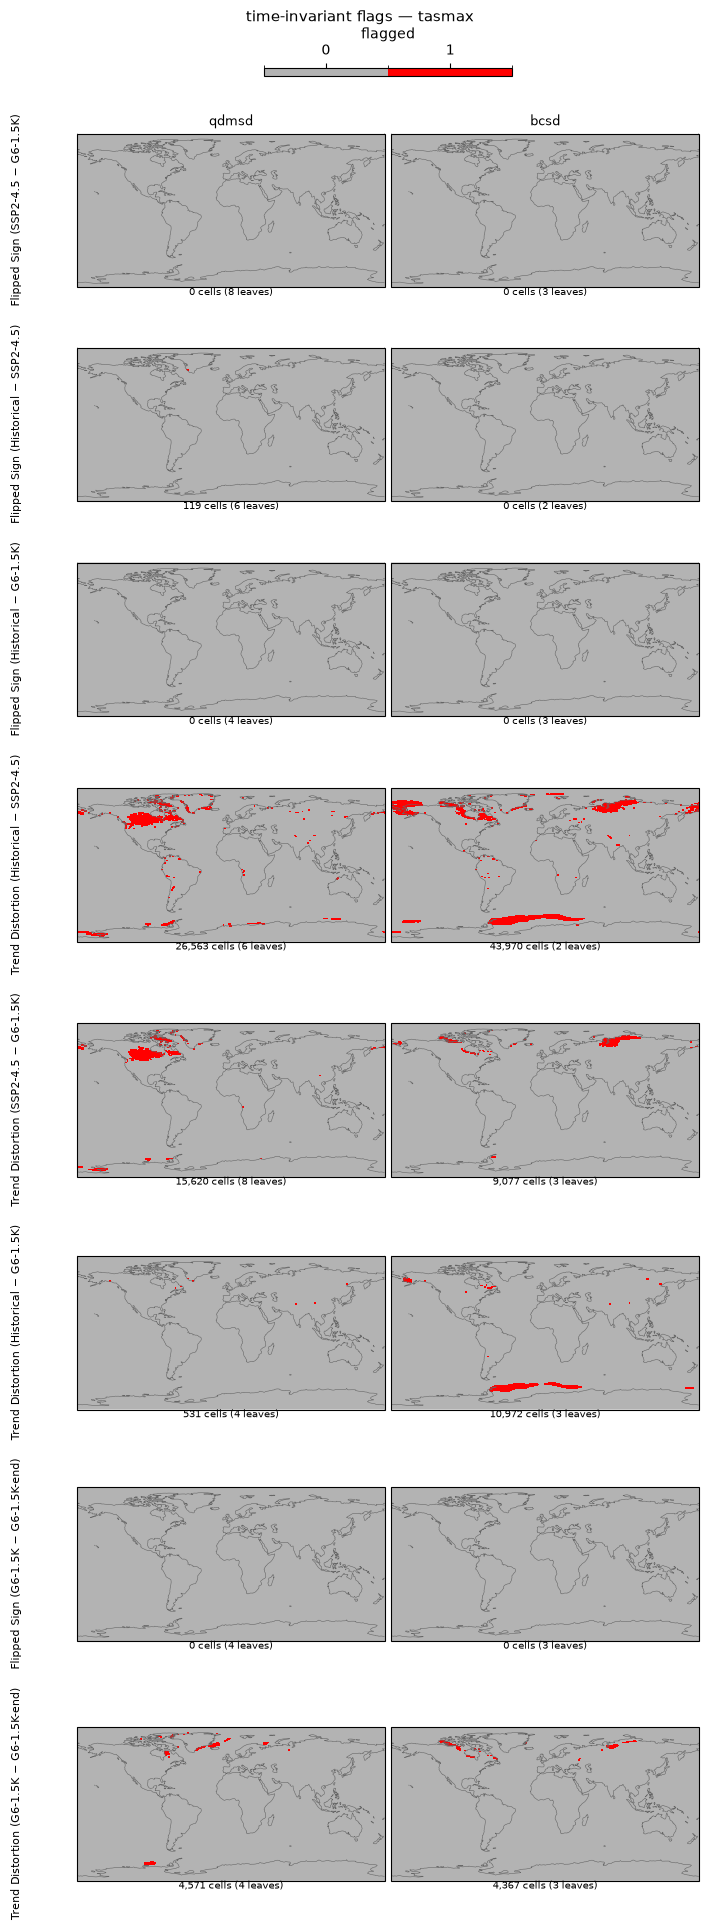

=== tasmin (15 leaves) ===


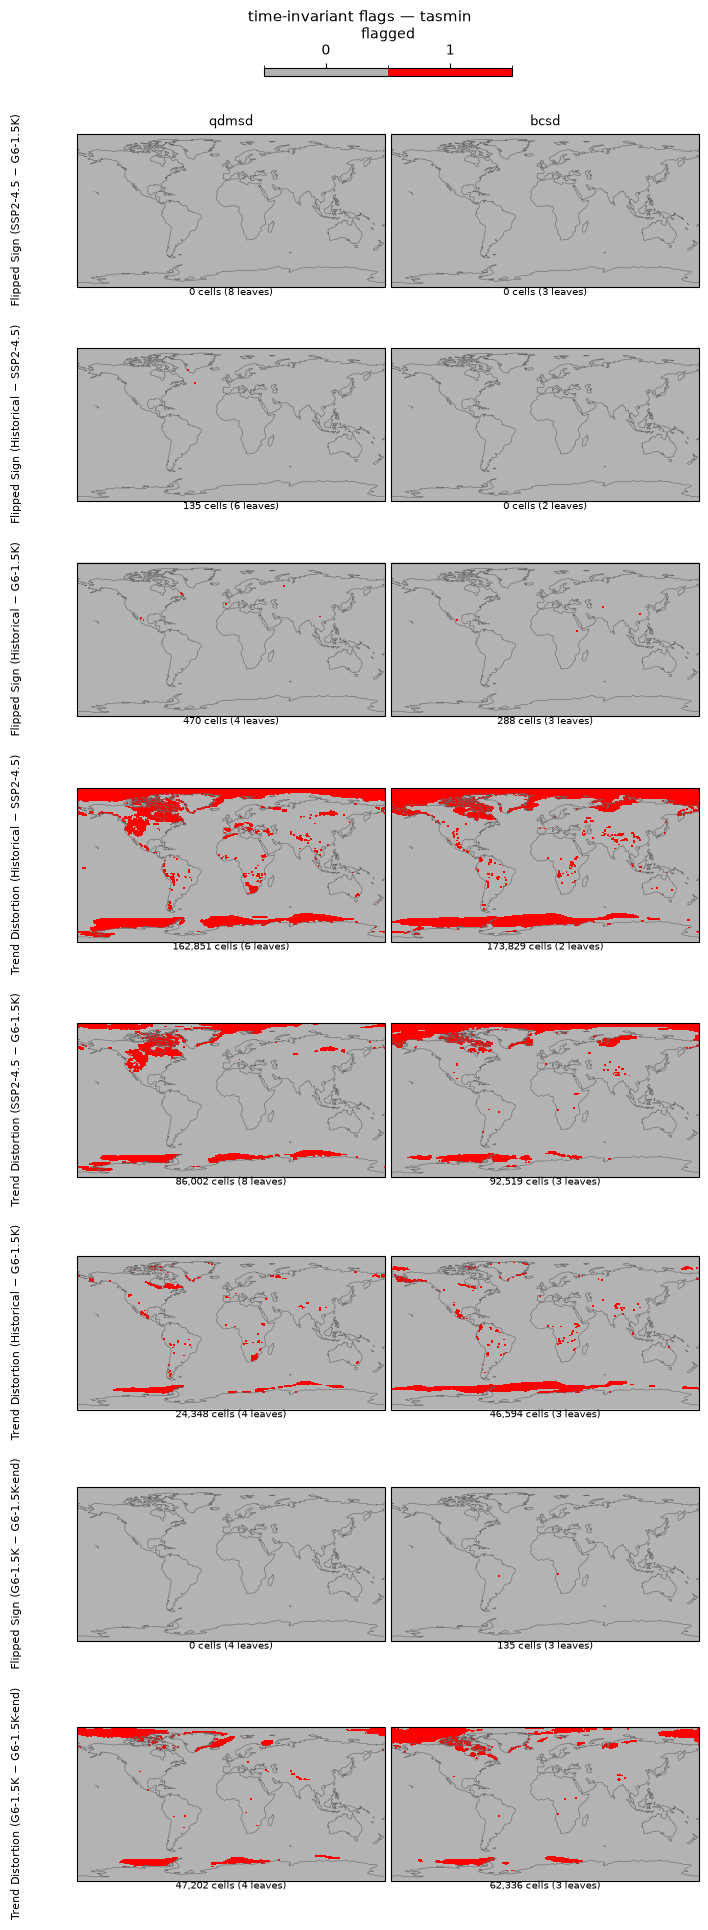

=== pr (24 leaves) ===


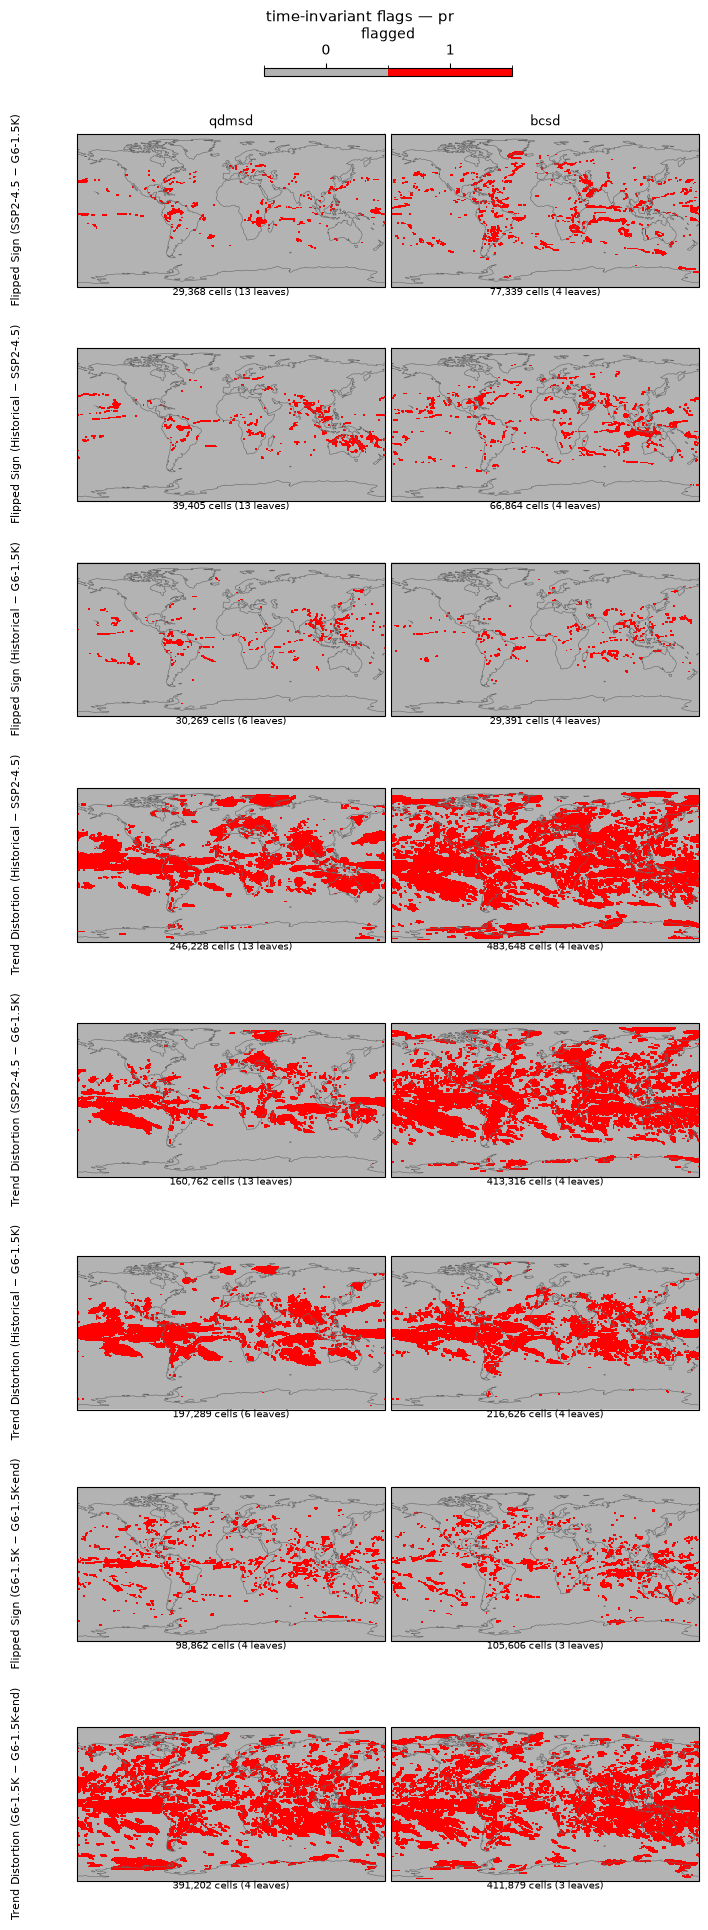

=== rsds (24 leaves) ===


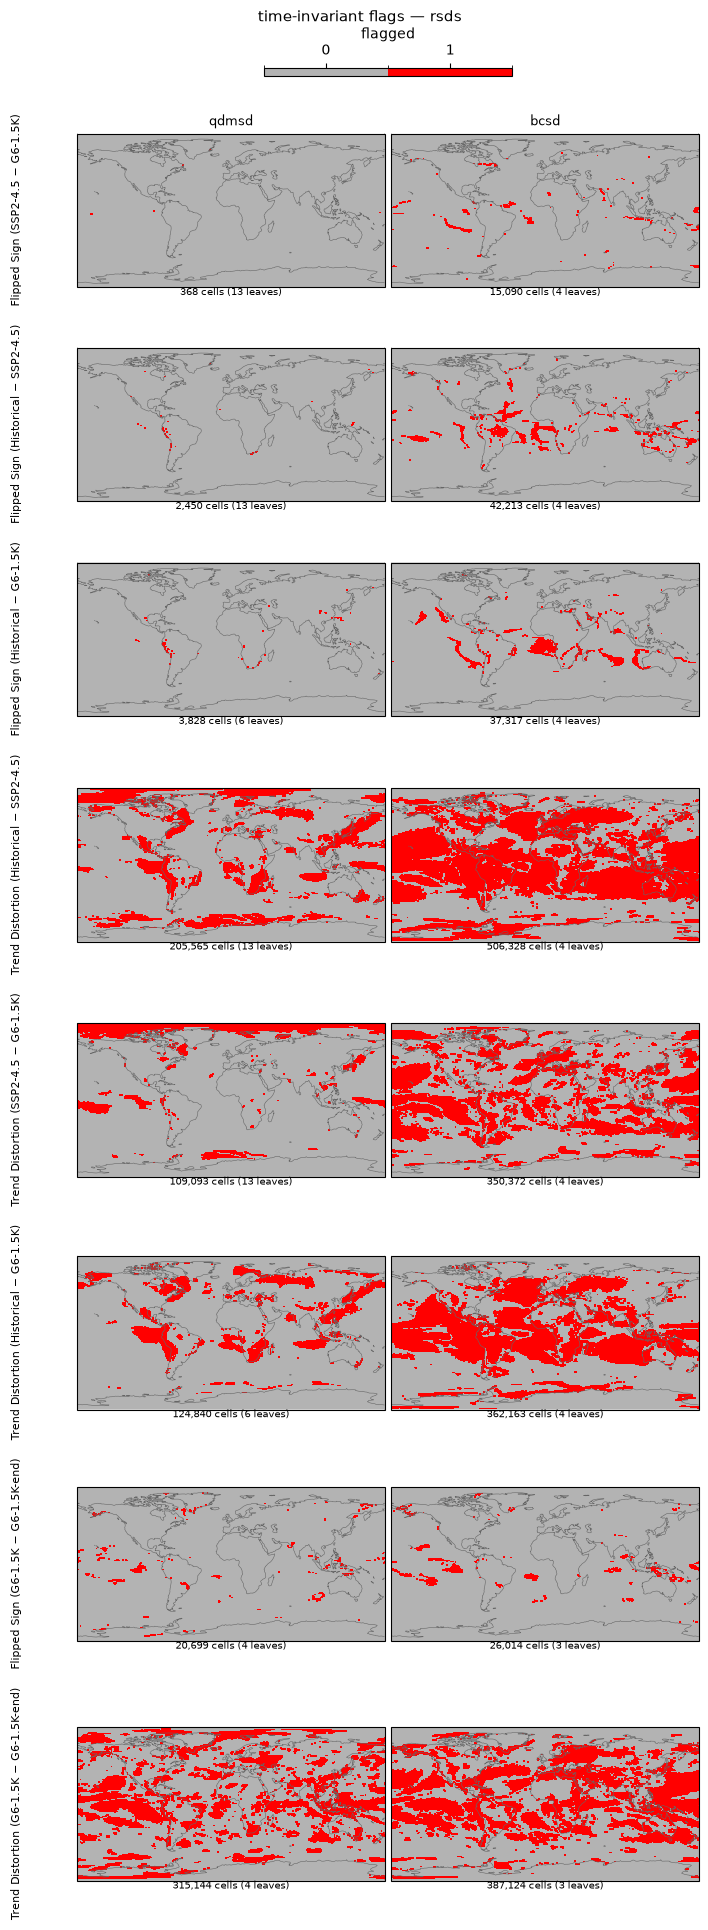

In [12]:
for variable in present_variables:
    var_df = tag_info[tag_info["variable"] == variable]
    print(f"=== {variable} ({len(var_df)} leaves) ===")
    plot_variable_time_invariant(variable, var_df)

## Time-varying flags (separate cell -- slow, saved to disk)

Kept in its own cell rather than merged into the loop above: it's much slower to draw
(one panel per ensemble member x scenario x source, for every flag), and re-running it
shouldn't clear the time-invariant figures already rendered above. Figures are saved as
PNGs to `FIGURE_DIR` (`./qa_flags_figures/`) instead of being displayed inline -- open
them there rather than waiting on this cell.

In [13]:
for variable in present_variables:
    var_df = tag_info[tag_info["variable"] == variable]
    print(f"=== {variable} ({len(var_df)} leaves) ===")
    plot_variable_time_varying(variable, var_df)

=== tas (24 leaves) ===
saved -> qa_flags_figures/time_varying_tas.png
=== tasmax (15 leaves) ===
saved -> qa_flags_figures/time_varying_tasmax.png
=== tasmin (15 leaves) ===
saved -> qa_flags_figures/time_varying_tasmin.png
=== pr (24 leaves) ===
saved -> qa_flags_figures/time_varying_pr.png
=== rsds (24 leaves) ===
saved -> qa_flags_figures/time_varying_rsds.png
